# Characteristic and Wigner functions through the transduction channel

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_laguerre

from src import (Transducer, aout_moments,
                 Phi_fock, Phi_coherent, Phi_gkp, Phi_out, integration_grid)
from src.plots import *
from src.params import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

### Parameters

In [ ]:
params = ROCHMAN_PARAMS          # ROCHMAN_PARAMS / KING_PARAMS / SAHU_PARAMS
IDEAL_COUPLING = True          # True sets eta_a = eta_b = 1

if IDEAL_COUPLING:
    params = {**params, 'eta_a': 1.0, 'eta_b': 1.0}

# Transducer at the transduction resonance, Delta = +omega_b.
device = Transducer.from_params(params, Delta=params['omega_b'])

# Parasitic squeezing ratio z = |g_bp/g_bs|, theory value from Delta_a.
z = 1# / abs(1 - (params['omega_b'] / params['Delta_a'])**2)

# Impedance-matched beam-splitter rate and the parasitic squeezing rate.
g_t = np.sqrt(params['kappa_a'] * params['kappa_b']) / 2
g_s = z * g_t

# Optical-output noise moments at the central frequency of transduction.
moments = aout_moments(*device.channel(params['omega_b'], g_t, g_s))

print(f"z = {z:.2e}   |S_12|^2 = {np.abs(moments[0])**2:.3f}")

z = 1.00e+00   |S_12|^2 = 0.121


### Transform

In [8]:
def wigner_from_chi(chi, R_chi, N_chi, R_w, N_w):
    """
    Wigner function W(b) = (1/pi**2) int d2z chi(z) exp(b z* - b* z), by direct
    quadrature. chi is sampled on |Re z|, |Im z| <= R_chi (N_chi points/axis);
    W is returned on |Re b|, |Im b| <= R_w (N_w points/axis). W is real.
    """
    z  = np.linspace(-R_chi, R_chi, N_chi)
    hz = z[1] - z[0]
    C  = chi(z[None, :] + 1j*z[:, None])          # chi grid: rows Im z, cols Re z

    b  = np.linspace(-R_w, R_w, N_w)              # phase-space axis, b = u + i v
    Kx = np.exp( 2j * np.outer(b, z))             # kernel factor, Im b <-> Re z
    Ky = np.exp(-2j * np.outer(b, z))             # kernel factor, Re b <-> Im z
    W  = (hz**2 / np.pi**2) * (Kx @ C.T) @ Ky.T
    return b, W.real


# Closed-form Wigner functions (2/pi normalisation) for the checks below.
def W_vacuum(b):      return 2/np.pi * np.exp(-2*np.abs(b)**2)
def W_coherent(b, a): return 2/np.pi * np.exp(-2*np.abs(b - a)**2)
def W_fock(b, n):     return 2/np.pi * (-1)**n * eval_laguerre(n, 4*np.abs(b)**2) * np.exp(-2*np.abs(b)**2)

### Checks

In [9]:
# wigner_from_chi vs. the closed forms, on a grid wide/fine enough for |b| <~ 5.
R_chk, N_chk = 8.0, 241
checks = [
    ('vacuum',            lambda w: Phi_coherent(w, 0.0),        lambda B: W_vacuum(B)),
    ('coherent sqrt(3)',  lambda w: Phi_coherent(w, np.sqrt(3)), lambda B: W_coherent(B, np.sqrt(3))),
    ('Fock |5>',          lambda w: Phi_fock(w, 5),              lambda B: W_fock(B, 5)),
]

for name, chi, ref in checks:
    b, W = wigner_from_chi(chi, R_chk, N_chk, 5.0, 161)
    B = b[None, :] + 1j*b[:, None]
    print(f"{name:18s}  max|W - analytic| = {np.abs(W - ref(B)).max():.1e}")

vacuum              max|W - analytic| = 6.0e-15
coherent sqrt(3)    max|W - analytic| = 5.8e-15
Fock |5>            max|W - analytic| = 9.5e-09


### Figure

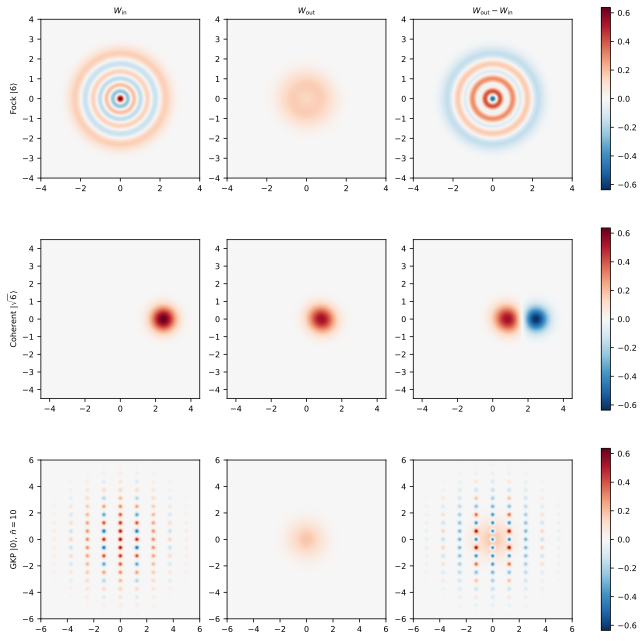

In [10]:
DOMAIN = 'wigner'   # 'chi' or 'wigner'

# (label, input chi, grid spec for the transform, chi view radius, b view radius).
rows = [
    (r'Fock $|6\rangle$',              lambda w: Phi_fock(w, 6),               ('fock', 6),     6.5, 4.0),
    (r'Coherent $|\sqrt{6}\rangle$',   lambda w: Phi_coherent(w, np.sqrt(6)),  ('coherent', 6), 5.0, 4.5),
    (r'GKP $|0\rangle$, $\bar n = 10$', lambda w: Phi_gkp(w, 10.0),             ('gkp', 10.0),   9.0, 6.0),
]

titles = {
    'chi':    (r'$\Phi_\mathrm{in}$', r'$\Phi_\mathrm{out}$', r'$\Phi_\mathrm{out} - \Phi_\mathrm{in}$'),
    'wigner': (r'$W_\mathrm{in}$',    r'$W_\mathrm{out}$',    r'$W_\mathrm{out} - W_\mathrm{in}$'),
}[DOMAIN]

fig, axs = plt.subplots(
    len(rows), 3,
    figsize = (2.6*FIG_SIZES['onecol'], 2.7*FIG_SIZES['onecol']),
    constrained_layout = True,
    )

for (label, chi_in, spec, R_chi, R_w), row_axs in zip(rows, axs):
    chi_out = lambda w, f=chi_in: Phi_out(w, f, *moments)

    if DOMAIN == 'chi':
        # chi on a square view window.
        t = np.linspace(-R_chi, R_chi, 241)
        grid = t[None, :] + 1j*t[:, None]
        F_in, F_out, R = np.real(chi_in(grid)), np.real(chi_out(grid)), R_chi
    else:
        # Wigner transform; chi sampled on its own integration grid.
        R_g, N_g = integration_grid(*spec, pts_per_feature=6)
        _, F_in  = wigner_from_chi(chi_in,  R_g, N_g, R_w, 221)
        _, F_out = wigner_from_chi(chi_out, R_g, N_g, R_w, 221)
        R = R_w

    # Shared colour scale per row: the input sets it, output and residual follow.
    vmax = np.abs(F_in).max()
    kw = dict(extent=[-R, R, -R, R], origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    for ax, data in zip(row_axs, (F_in, F_out, F_out - F_in)):
        im = ax.imshow(data, **kw)
    row_axs[0].set_ylabel(label)
    fig.colorbar(im, ax=row_axs, shrink=0.85)

for ax, t in zip(axs[0], titles):
    ax.set_title(t)

fname = 'wigner_functions' if DOMAIN == 'wigner' else 'characteristic_functions'
fig.savefig(f'fig/{fname}.pdf', bbox_inches='tight')